#### Getting the data

In [85]:
import pandas as pd
import numpy as np
import seaborn as sns

df = pd.read_csv('https://raw.githubusercontent.com/alexeygrigorev/datasets/master/car_fuel_efficiency.csv')

In [86]:
df.head()

,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,model_year,origin,fuel_type,drivetrain,num_doors,fuel_efficiency_mpg
0,170,3.0,159.0,3413.433759,17.7,2003,Europe,Gasoline,All-wheel drive,0.0,13.231729
1,130,5.0,97.0,3149.664934,17.8,2007,USA,Gasoline,Front-wheel drive,0.0,13.688217
2,170,NaN,78.0,3079.038997,15.1,2018,Europe,Gasoline,Front-wheel drive,0.0,14.246341
3,220,4.0,NaN,2542.392402,20.2,2009,USA,Diesel,All-wheel drive,2.0,16.912736
4,210,1.0,140.0,3460.870990,14.4,2009,Europe,Gasoline,All-wheel drive,2.0,12.488369


In [87]:
df = df.loc[:, ['engine_displacement',
                 'horsepower',
                 'vehicle_weight',
                 'model_year',
                 'fuel_efficiency_mpg']]

In [88]:
df.head()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,170,159.0,3413.433759,2003,13.231729
1,130,97.0,3149.664934,2007,13.688217
2,170,78.0,3079.038997,2018,14.246341
3,220,NaN,2542.392402,2009,16.912736
4,210,140.0,3460.870990,2009,12.488369


#### Exploratory Data Analysis

<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

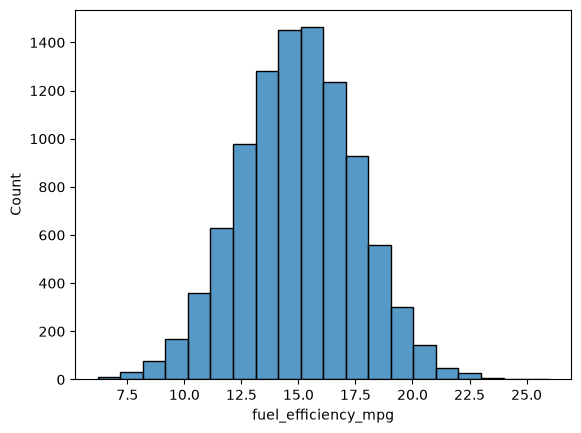

In [89]:
sns.histplot(df.fuel_efficiency_mpg, bins=20)

<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

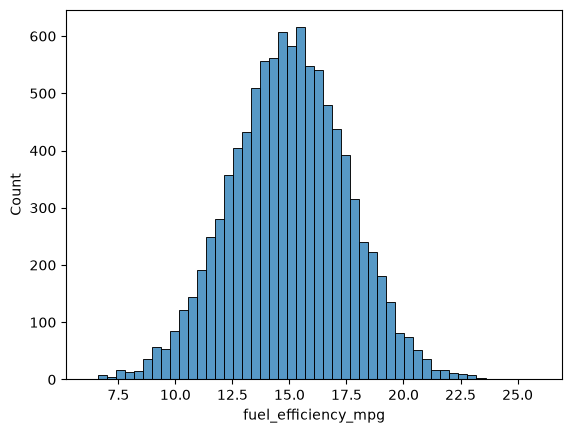

In [90]:
sns.histplot(df.fuel_efficiency_mpg, bins=50)

In [91]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9704 entries, 0 to 9703
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   engine_displacement  9704 non-null   int64  
 1   horsepower           8996 non-null   float64
 2   vehicle_weight       9704 non-null   float64
 3   model_year           9704 non-null   int64  
 4   fuel_efficiency_mpg  9704 non-null   float64
dtypes: float64(3), int64(2)
memory usage: 379.2 KB


In [92]:
df.describe()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
count,9704.000000,8996.000000,9704.000000,9704.000000,9704.000000
mean,199.708368,149.657292,3001.280993,2011.484027,14.985243
std,49.455319,29.879555,497.894860,6.659808,2.556468
min,10.000000,37.000000,952.681761,2000.000000,6.200971
25%,170.000000,130.000000,2666.248985,2006.000000,13.267459
50%,200.000000,149.000000,2993.226296,2012.000000,15.006037
75%,230.000000,170.000000,3334.957039,2017.000000,16.707965
max,380.000000,271.000000,4739.077089,2023.000000,25.967222


In [93]:
df.isna().sum()

engine_displacement      0
horsepower             708
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

#### Preparing Data

In [94]:
np.random.seed(42)

In [95]:
index = np.arange(len(df))

In [96]:
index[:10]

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [97]:
np.random.shuffle(index)

In [98]:
index[:10]

array([ 483, 7506, 8795, 1688, 6217, 4562, 5885, 3746, 7109, 2698])

In [99]:
validation_size = int(len(df) * 0.2)
test_size = int(len(df) * 0.2)
train_size = len(df) - validation_size - test_size

In [100]:
print(train_size)
print(validation_size)
print(test_size)

5824
1940
1940


In [101]:
print(train_size)
print(validation_size)
print(test_size)

5824
1940
1940


In [102]:
train_df = df.iloc[index[:train_size]]
validation_df = df.iloc[index[train_size:train_size + validation_size]] 
test_df = df.iloc[index[train_size + validation_size:]]

In [103]:
train_df.reset_index(drop=True, inplace=True)
validation_df.reset_index(drop=True, inplace=True)
test_df.reset_index(drop=True, inplace=True)

In [104]:
y_train = train_df.fuel_efficiency_mpg.values
y_validation = validation_df.fuel_efficiency_mpg.values
y_test = test_df.fuel_efficiency_mpg.values

In [105]:
train_df = train_df.drop('fuel_efficiency_mpg', axis=1)
validation_df = validation_df.drop('fuel_efficiency_mpg', axis=1)
test_df = test_df.drop('fuel_efficiency_mpg', axis=1)

#### Training linear regression

In [106]:
def prepare_x(df, null_replacement = 'zero'):
    df = df.copy()
    if null_replacement == 'mean':
        df['horsepower'] = df['horsepower'].fillna(df['horsepower'].mean())
    if null_replacement == 'zero':
        df['horsepower'] = df['horsepower'].fillna(0)
    X = np.array(df)
    return X

In [107]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])
    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w = XTX_inv.dot(X.T).dot(y)
    return w[0], w[1:]

In [126]:
def rmse(y_true, y_pred):
    return np.sqrt(((y_true - y_pred) ** 2).mean())

In [109]:
for replacement in ['zero', 'mean']:
    train_x = prepare_x(train_df, null_replacement=replacement)
    w0, w = train_linear_regression(train_x, y_train)
    y_pred = w0 + train_x.dot(w)
    rmse_train = rmse(y_train, y_pred)
    print(f'RMSE for null replacement "{replacement}": {round(rmse_train, 2)}')


RMSE for null replacement "zero": 0.52
RMSE for null replacement "mean": 0.46


#### Train linear regression with regularization

In [110]:
def train_linear_regression_reg(X, y, r):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])
    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])
    XTX_inv = np.linalg.inv(XTX)
    w = XTX_inv.dot(X.T).dot(y)
    return w[0], w[1:]

In [111]:
for r in [0, 0.01, 0.1, 1, 5, 10, 100]:
    train_x = prepare_x(train_df, null_replacement='zero')
    w0, w = train_linear_regression_reg(train_x, y_train, r)
    y_pred = w0 + train_x.dot(w)
    rmse_train = rmse(y_train, y_pred)
    print(f'RMSE for regularization parameter "{r}": {round(rmse_train, 5)}')

RMSE for regularization parameter "0": 0.52026
RMSE for regularization parameter "0.01": 0.52042
RMSE for regularization parameter "0.1": 0.52351
RMSE for regularization parameter "1": 0.52795
RMSE for regularization parameter "5": 0.52874
RMSE for regularization parameter "10": 0.52884
RMSE for regularization parameter "100": 0.52894


#### Different seeds

In [115]:
rmses = []
for s in [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]:
    np.random.seed(s)
    index = np.arange(len(df))
    np.random.shuffle(index)
    validation_size = int(len(df) * 0.2)
    test_size = int(len(df) * 0.2)
    train_size = len(df) - validation_size - test_size
    df_shuffled = df.iloc[index]
    train_df = df_shuffled.iloc[:train_size].copy()
    validation_df = df_shuffled.iloc[train_size:train_size+validation_size].copy()
    test_df = df_shuffled.iloc[train_size+validation_size:].copy()
    train_df.reset_index(drop=True, inplace=True)
    validation_df.reset_index(drop=True, inplace=True)
    test_df.reset_index(drop=True, inplace=True)
    y_train = train_df.fuel_efficiency_mpg.values
    y_validation = validation_df.fuel_efficiency_mpg.values
    y_test = test_df.fuel_efficiency_mpg.values
    train_df = train_df.drop('fuel_efficiency_mpg', axis=1)
    validation_df = validation_df.drop('fuel_efficiency_mpg', axis=1)
    test_df = test_df.drop('fuel_efficiency_mpg', axis=1)
    train_x = prepare_x(train_df, null_replacement=replacement)
    w0, w = train_linear_regression(train_x, y_train)
    y_pred = w0 + train_x.dot(w)
    rmse_train = rmse(y_train, y_pred)
    rmses.append(rmse_train)
print(round(np.std(rmses), 3))


0.003


#### Combining training and validation datasets

In [127]:
np.random.seed(s)
index = np.arange(len(df))
np.random.shuffle(index)
validation_size = int(len(df) * 0.2)
test_size = int(len(df) * 0.2)
train_size = len(df) - validation_size - test_size
df_shuffled = df.iloc[index]
train_df = df_shuffled.iloc[:train_size].copy()
validation_df = df_shuffled.iloc[train_size:train_size+validation_size].copy()
test_df = df_shuffled.iloc[train_size+validation_size:].copy()
train_df.reset_index(drop=True, inplace=True)
validation_df.reset_index(drop=True, inplace=True)
test_df.reset_index(drop=True, inplace=True)
y_train = train_df.fuel_efficiency_mpg.values
y_validation = validation_df.fuel_efficiency_mpg.values
y_test = test_df.fuel_efficiency_mpg.values
train_df = train_df.drop('fuel_efficiency_mpg', axis=1)
validation_df = validation_df.drop('fuel_efficiency_mpg', axis=1)
test_df = test_df.drop('fuel_efficiency_mpg', axis=1)
train_val_df = pd.concat([train_df, validation_df], axis=0)
y_train_val = np.concatenate([y_train, y_validation])
train_x = prepare_x(train_val_df, null_replacement="zero")
w0, w = train_linear_regression_reg(train_x, y_train_val, r = 0.001)
y_pred = w0 + train_x.dot(w)
rmse_val = rmse(y_train_val, y_pred)

In [128]:
rmse_val

np.float64(0.5197448026201141)